# Linear Transformation Exercises

A **linear transformation** $T: \mathbb{R}^2 \to \mathbb{R}^2$ maps every point $(x, y)$ to a
new point $(x', y')$ using a 2×2 matrix:

$$\begin{bmatrix} x' \\ y' \end{bmatrix} = T \begin{bmatrix} x \\ y \end{bmatrix}$$

**Properties every linear transformation shares:**
- The origin always maps to itself: $T(\mathbf{0}) = \mathbf{0}$
- Straight lines remain straight lines
- Parallel lines remain parallel

This notebook covers **15 fundamental 2D linear transformations**.
For each one: read the explanation, then complete the code in the exercise cell below.

| # | Transformation |
|---|----------------|
| 1 | Identity |
| 2 | Uniform Scaling |
| 3 | Non-uniform Scaling |
| 4 | Rotation |
| 5 | Reflection over x-axis |
| 6 | Reflection over y-axis |
| 7 | Reflection over origin |
| 8 | Reflection over y = x |
| 9 | Reflection over y = −x |
| 10 | Horizontal Shear |
| 11 | Vertical Shear |
| 12 | Projection onto x-axis |
| 13 | Projection onto y-axis |
| 14 | Squeeze Mapping |
| 15 | Composition of Transformations |

> **Libraries used:** `numpy` and `matplotlib` only.


In [1]:
import numpy as np
import matplotlib.pyplot as plt


def linear_transform(T, x, y):
    """Apply a 2x2 linear transformation matrix T to points (x, y).

    Parameters
    ----------
    T : ndarray of shape (2, 2)
        The transformation matrix.
    x : array-like
        x-coordinates of the input points.
    y : array-like
        y-coordinates of the input points.

    Returns
    -------
    x_new : ndarray
        Transformed x-coordinates.
    y_new : ndarray
        Transformed y-coordinates.
    """
    points = np.vstack([np.asarray(x, dtype=float),
                        np.asarray(y, dtype=float)])  # shape (2, N)
    transformed = T @ points                          # shape (2, N)
    return transformed[0], transformed[1]


def plot_transform(x_orig, y_orig, x_new, y_new,
                   title='Linear Transformation', figsize=(7, 7)):
    """Plot the original and transformed shapes on the same axes."""
    plt.figure(figsize=figsize)
    plt.plot(x_orig, y_orig, 'b-o', linewidth=2, markersize=5, label='Original')
    plt.plot(x_new,  y_new,  'r--o', linewidth=2, markersize=5, label='Transformed')
    plt.axhline(0, color='gray', linewidth=0.8)
    plt.axvline(0, color='gray', linewidth=0.8)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.tight_layout()
    plt.show()


print('Helper functions loaded: linear_transform, plot_transform')


Helper functions loaded: linear_transform, plot_transform


## Base Shape

Throughout this notebook we use a **unit square** as the test shape.
Its corners are $(0,0) \to (1,0) \to (1,1) \to (0,1) \to (0,0)$.

Run the cell below to define `x_shape` and `y_shape`, which you will reuse in every exercise.


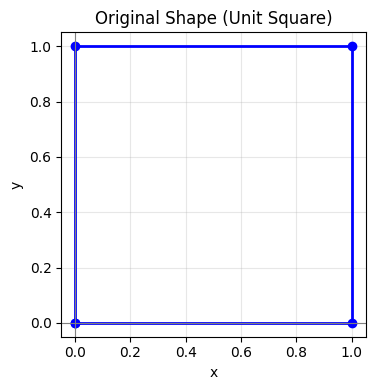

In [2]:
# Unit square: (0,0) -> (1,0) -> (1,1) -> (0,1) -> (0,0)
x_shape = np.array([0, 1, 1, 0, 0], dtype=float)
y_shape = np.array([0, 0, 1, 1, 0], dtype=float)

plt.figure(figsize=(4, 4))
plt.plot(x_shape, y_shape, 'b-o', linewidth=2, markersize=6)
plt.axhline(0, color='gray', linewidth=0.8)
plt.axvline(0, color='gray', linewidth=0.8)
plt.gca().set_aspect('equal')
plt.grid(alpha=0.3)
plt.title('Original Shape (Unit Square)')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.show()


---
## 1. Identity Transformation

The **identity transformation** maps every point to itself — the shape is completely unchanged.

$$I = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}$$

For any vector $\mathbf{v}$: $\; I\mathbf{v} = \mathbf{v}$.

### Properties
| Property | Value |
|----------|-------|
| Determinant | $1$ |
| Eigenvalues | $1,\ 1$ |
| Area change | None |
| Invertible? | Yes $\;(I^{-1} = I)$ |

### Real-world Application
- **Computer graphics pipelines (OpenGL / WebGL):** The model matrix starts as the identity — the "do nothing" baseline before rotations, scales, and translations are composed on top.
- **Control systems:** An identity response means no modification to the signal, used as a reference when verifying that a controller is actually doing something.
- **Unit testing ML pipelines:** Multiplying by the identity confirms your matrix multiplication code is correct before adding complexity.


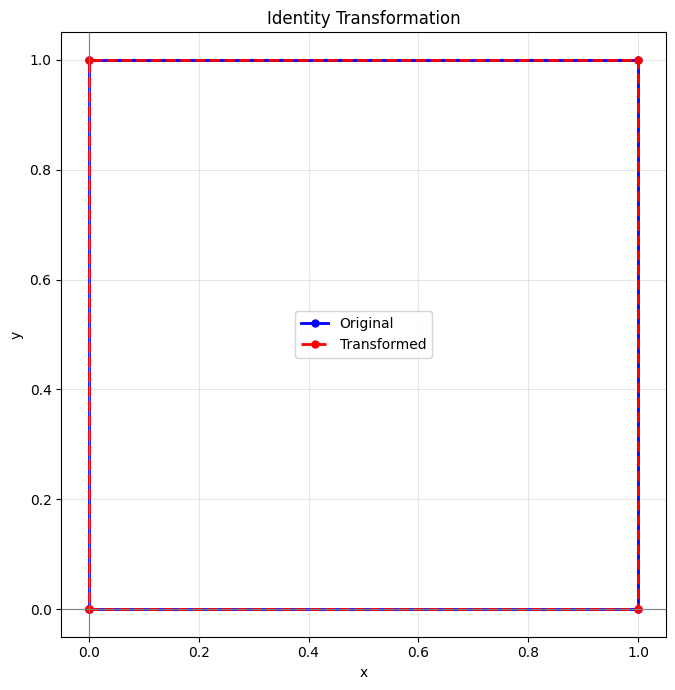

In [3]:
# ── Exercise 1 · Identity Transformation ─────────────────────────────────
# The identity matrix leaves every point unchanged.

# Step 1: Define the 2×2 identity transformation matrix T
T = np.array([[1, 0],
              [0, 1]])

# Step 2: Apply the transformation using linear_transform
x_new, y_new = linear_transform(T, x_shape, y_shape)

# Step 3: Plot — original and transformed should overlap completely
plot_transform(x_shape, y_shape, x_new, y_new, title='Identity Transformation')


---
## 2. Uniform Scaling (Dilation / Contraction)

**Uniform scaling** stretches or shrinks a shape equally in every direction by factor $k$:

$$S = \begin{bmatrix} k & 0 \\ 0 & k \end{bmatrix}$$

- $k > 1$: enlarges (dilation)
- $0 < k < 1$: shrinks (contraction)
- $k < 0$: scales **and** flips through the origin

### Properties
| Property | Value |
|----------|-------|
| Determinant | $k^2$ |
| Eigenvalues | $k,\ k$ |
| Area change | Multiplied by $k^2$ |
| Preserves angles? | Yes |

### Real-world Application
- **Map applications (Google Maps):** Zooming in or out applies a uniform scale to all tile coordinates. Each zoom level is a factor-of-2 scale.
- **Image resizing (proportional):** "Fit to window" while preserving aspect ratio is a uniform scale.
- **Video games:** Scaling an enemy sprite or 3D model larger uniformly over time (e.g., a boss growing as it takes damage).
- **Unit conversion (physics):** Converting metres to centimetres scales every dimension by 100.


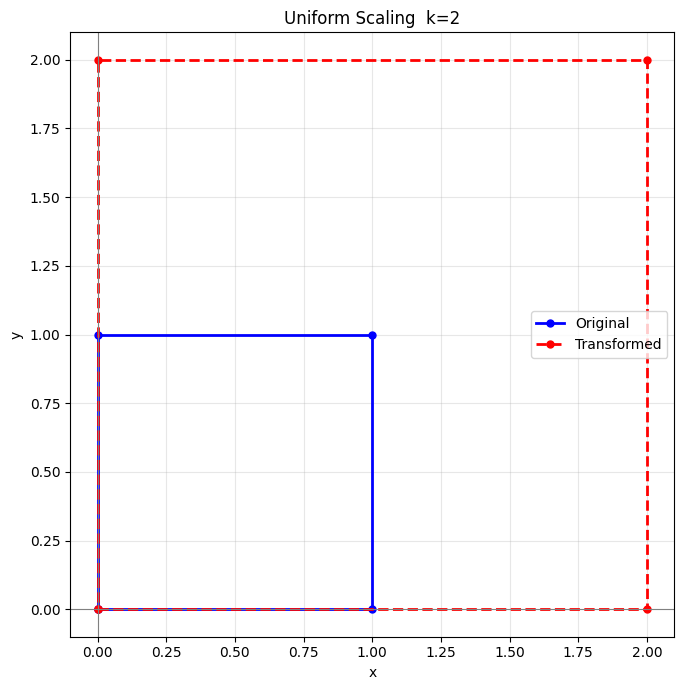

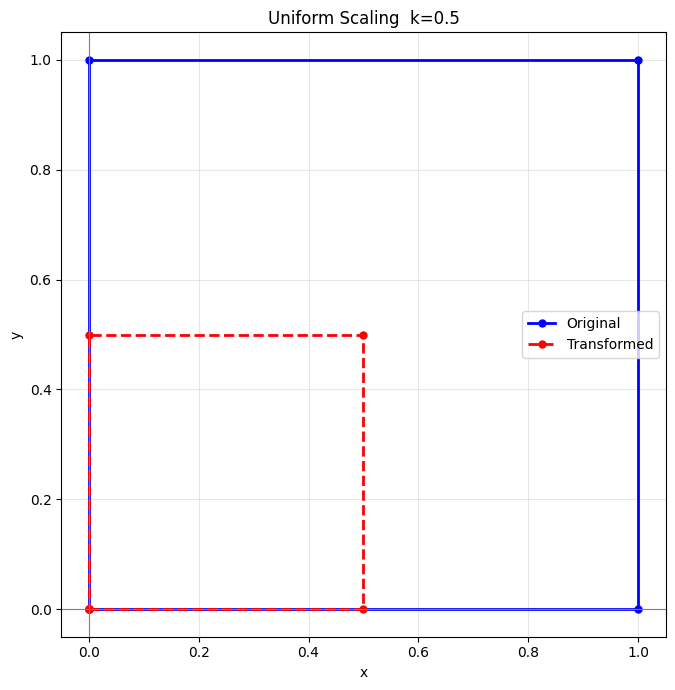

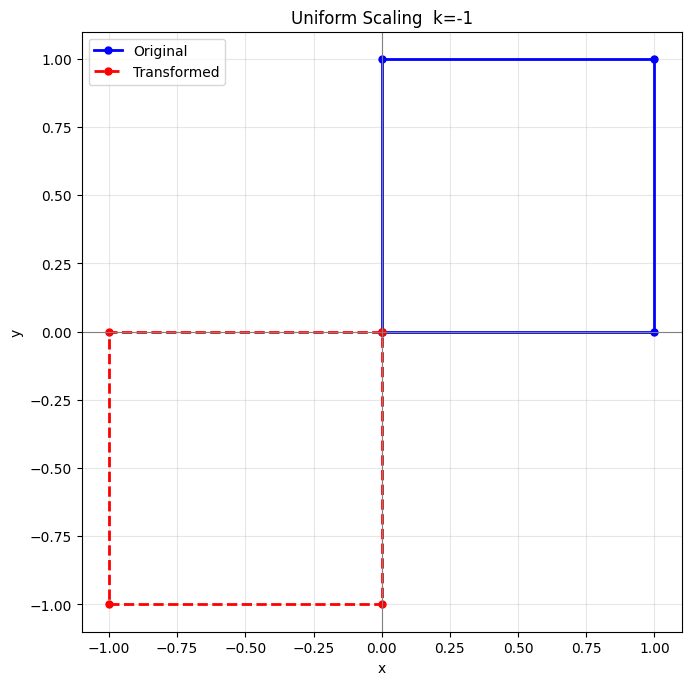

In [4]:
# ── Exercise 2 · Uniform Scaling ─────────────────────────────────────────
# Scale the unit square equally in ALL directions by factor k.
# Try k=2 (double), k=0.5 (half), k=-1 (flip through origin).

k_values = [2, 0.5, -1]  # scaling factors to try

for k in k_values:
    # Step 1: Define the uniform scaling matrix
    T = np.array([[k, 0],
                  [0, k]])

    # Step 2: Apply the transformation
    x_new, y_new = linear_transform(T, x_shape, y_shape)

    # Step 3: Plot
    plot_transform(x_shape, y_shape, x_new, y_new,
                   title=f'Uniform Scaling  k={k}')


---
## 3. Non-uniform Scaling

**Non-uniform scaling** stretches/compresses each axis independently:

$$S = \begin{bmatrix} k_x & 0 \\ 0 & k_y \end{bmatrix}$$

- $k_x$ controls **horizontal** scaling
- $k_y$ controls **vertical** scaling

When $k_x \neq k_y$ the shape is distorted: a square becomes a rectangle.

### Properties
| Property | Value |
|----------|-------|
| Determinant | $k_x \cdot k_y$ |
| Eigenvalues | $k_x,\ k_y$ |
| Area change | Multiplied by $\lvert k_x \cdot k_y \rvert$ |
| Preserves angles? | Only when $k_x = k_y$ |

### Real-world Application
- **Image editing (Photoshop / GIMP):** The "Scale" tool with separate width and height values — stretching a photo horizontally to fill a banner.
- **CSS transforms:** `transform: scaleX(2) scaleY(0.5)` applies different scales to each axis.
- **Machine learning feature scaling:** Min–max normalisation scales each feature dimension independently (equivalent to a non-uniform scale in feature space).
- **Seismic sensors:** Amplitudes along different sensor axes are calibrated independently.


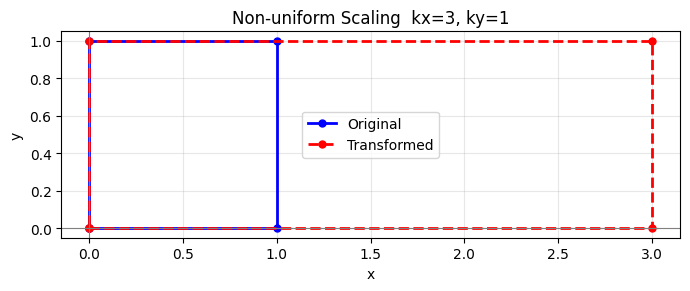

In [5]:
# ── Exercise 3 · Non-uniform Scaling ─────────────────────────────────────
# Scale the x-axis by kx and the y-axis by ky independently.
# Try kx=3, ky=1 (stretch wide)  or  kx=1, ky=3 (stretch tall).

kx = 3   # horizontal scale
ky = 1   # vertical scale

# Step 1: Define the non-uniform scaling matrix
T = np.array([[kx,0],
              [0,ky]])

# Step 2: Apply the transformation
x_new, y_new = linear_transform(T, x_shape, y_shape)

# Step 3: Plot
plot_transform(x_shape, y_shape, x_new, y_new,
               title=f'Non-uniform Scaling  kx={kx}, ky={ky}')


---
## 4. Rotation

A **rotation** by angle $\theta$ (counter-clockwise) maps every point around the origin:

$$R(\theta) = \begin{bmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{bmatrix}$$

### Properties
| Property | Value |
|----------|-------|
| Determinant | $1$ |
| Eigenvalues | $e^{i\theta},\ e^{-i\theta}$ (complex) |
| Area change | None |
| Preserves distances? | Yes (orthogonal: $R^T R = I$) |
| Inverse | $R^{-1} = R(-\theta) = R^T$ |

### Real-world Application
- **Video games & 3D engines (Unity, Unreal Engine):** Rotating a character, camera, or object uses rotation matrices (or quaternions that decompose to them).
- **Robotics (forward kinematics):** Each joint of a robot arm applies a rotation to the local coordinate frame. Chaining these rotations gives the end-effector position.
- **Computer vision:** Rotating camera frames to match a world frame uses rotation matrices (extrinsic calibration).
- **Signal processing:** In-phase / quadrature (I/Q) signal demodulation rotates the baseband signal by $\theta$.


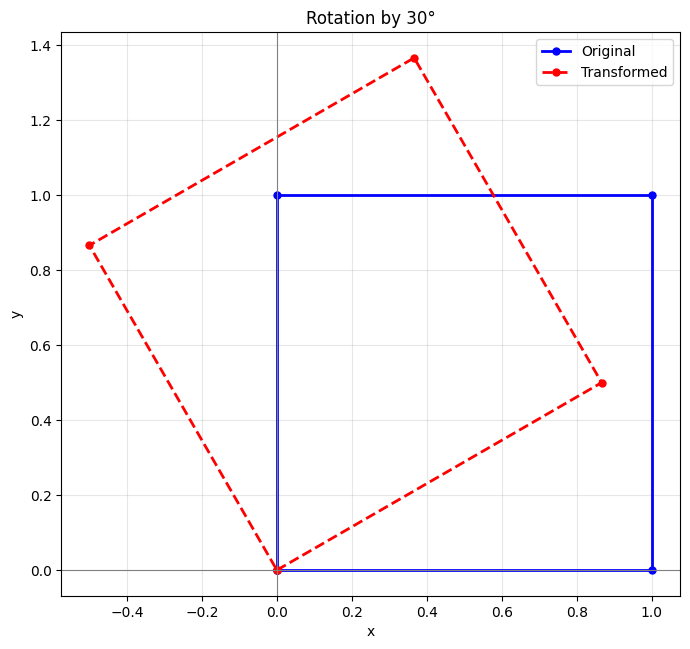

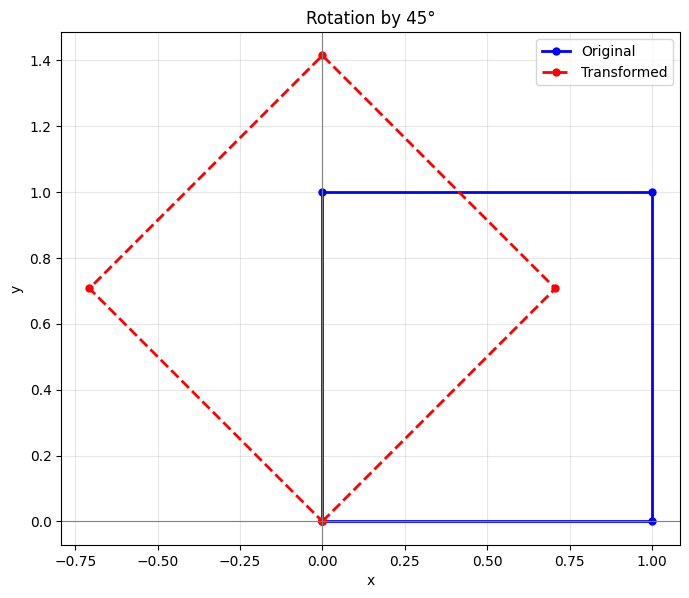

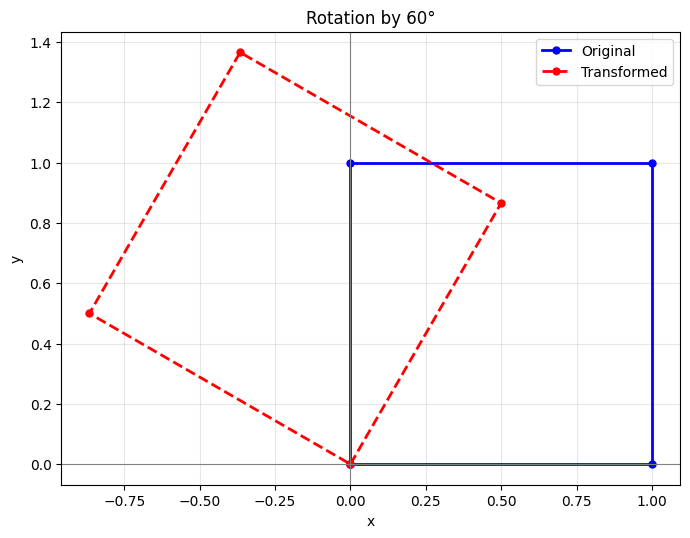

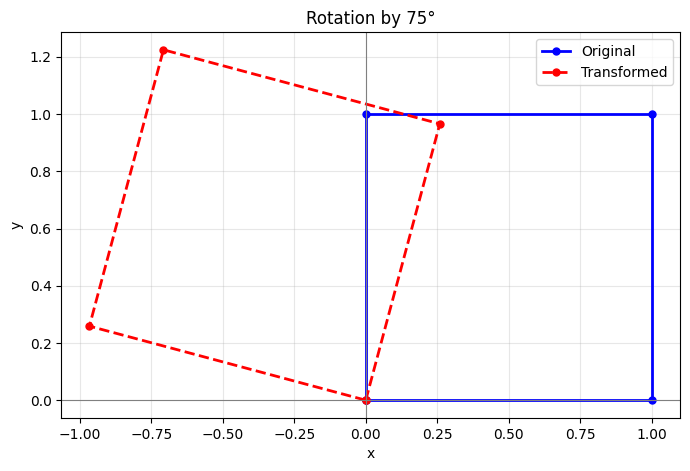

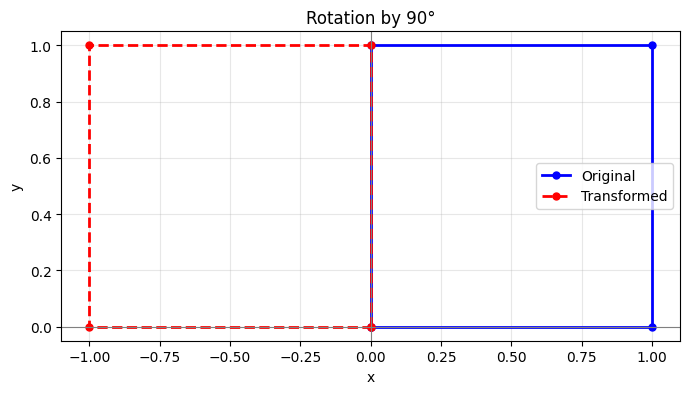

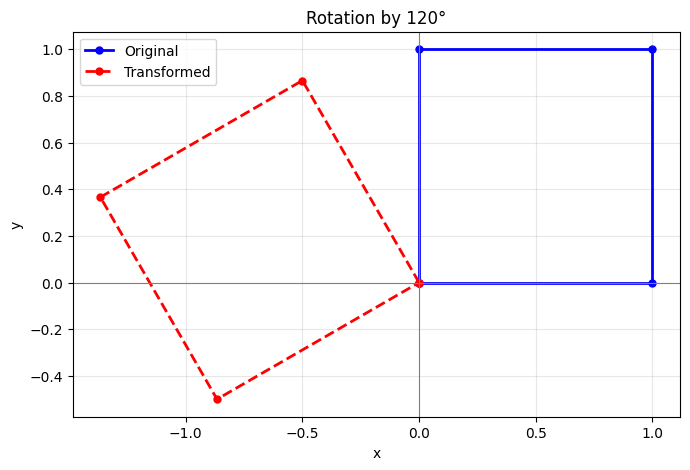

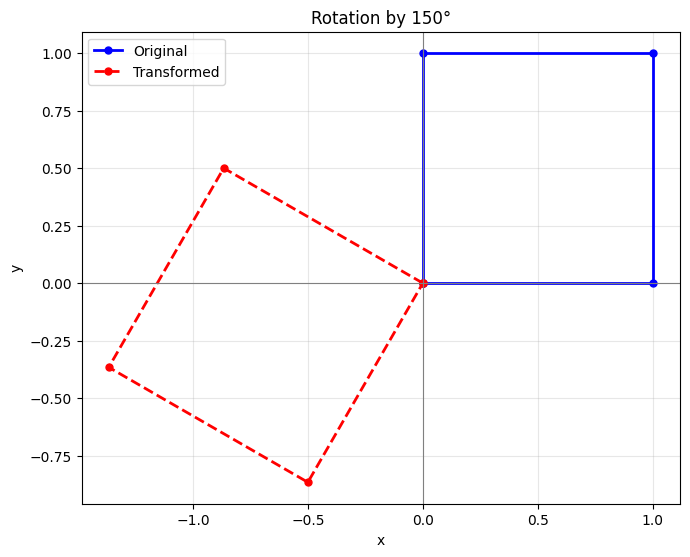

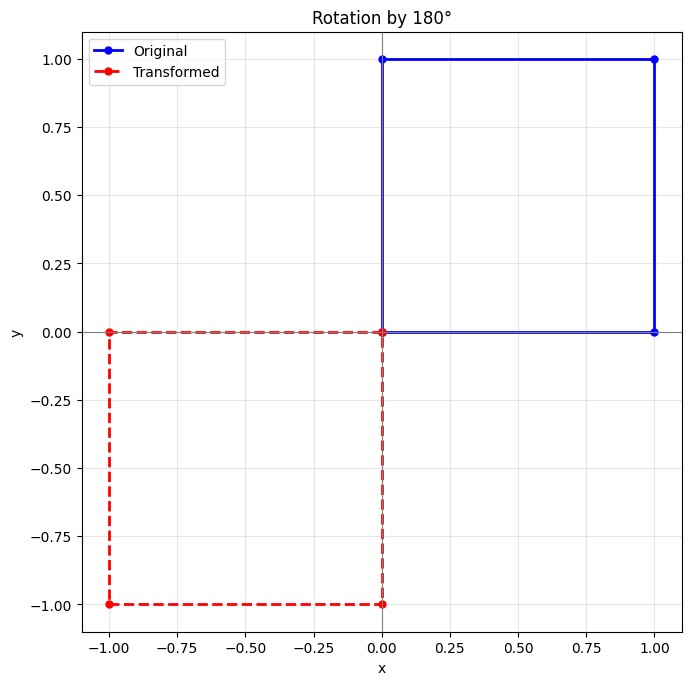

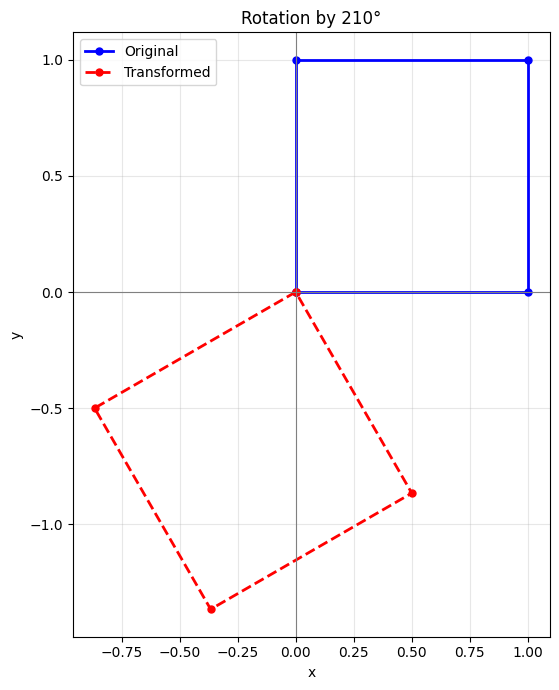

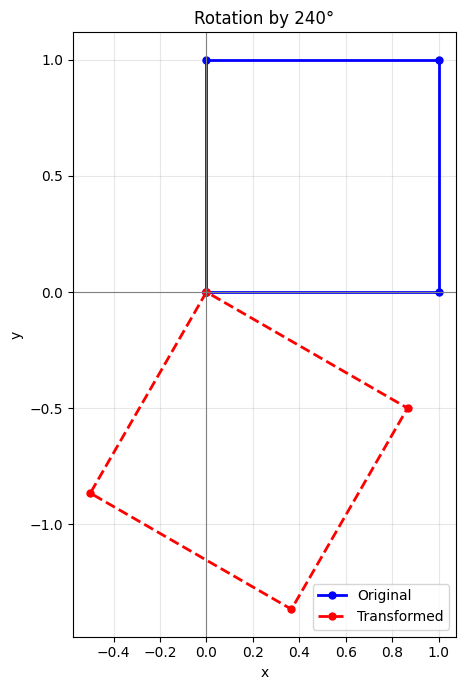

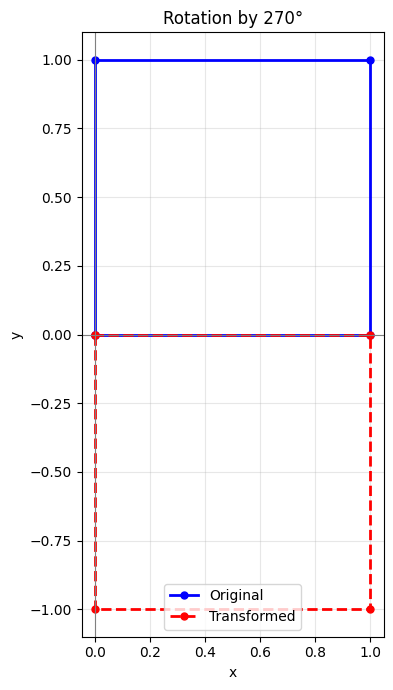

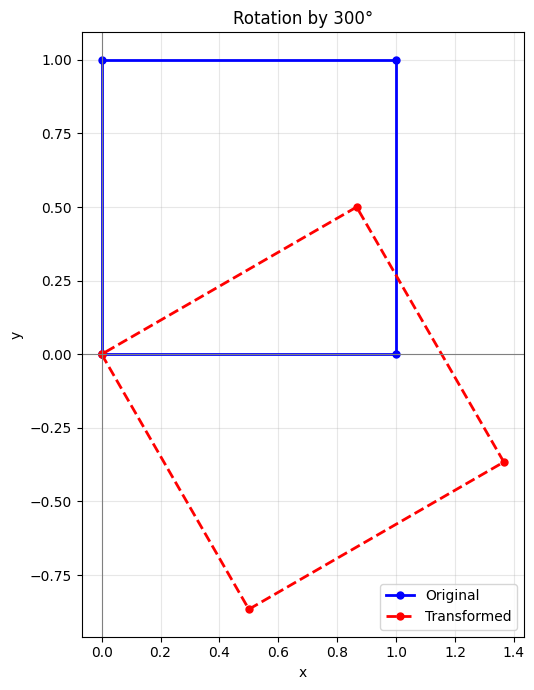

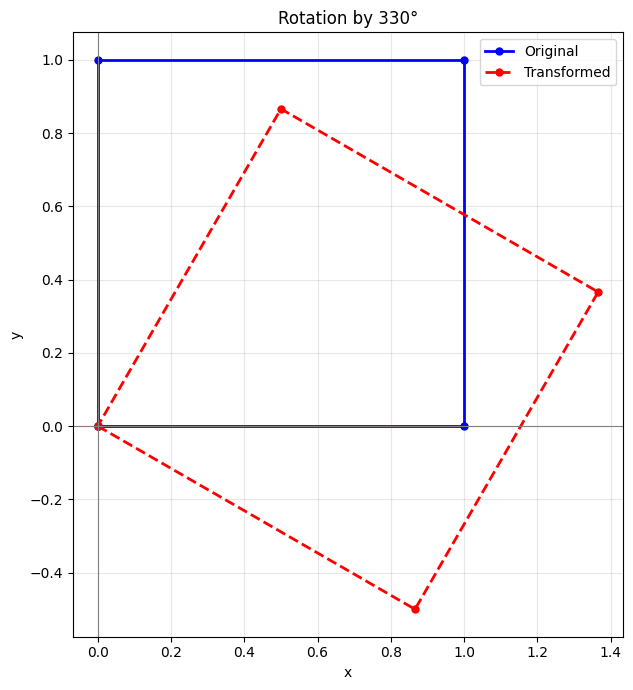

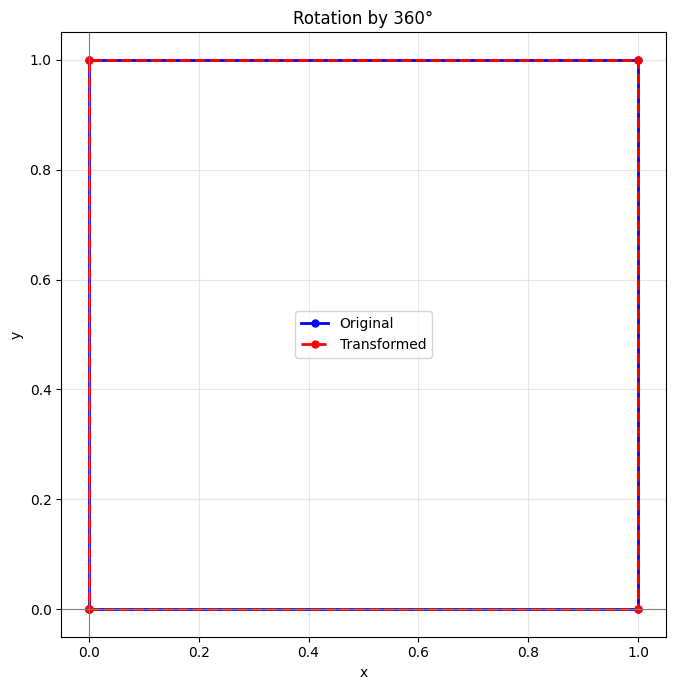

In [6]:
# ── Exercise 4 · Rotation ─────────────────────────────────────────────────
# Rotate the unit square counter-clockwise by angle theta.
# numpy trig functions expect radians — use np.radians() to convert.

thetas =[
    np.radians(30), 
    np.radians(45),
    np.radians(60),
    np.radians(75),
    np.radians(90),
    np.radians(120),
    np.radians(150),
    np.radians(180),
    np.radians(210),
    np.radians(240),
    np.radians(270),
    np.radians(300),
    np.radians(330),
    np.radians(360),
]   # try 30, 45, 90, 120, 180 degrees

for theta in thetas:
    # Step 1: Define the rotation matrix using np.cos and np.sin
    T = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])
    
    # Step 2: Apply the transformation
    x_new, y_new = linear_transform(T, x_shape, y_shape)
    
    # Step 3: Plot
    plot_transform(x_shape, y_shape, x_new, y_new,
                   title=f'Rotation by {np.degrees(theta):.0f}°')


---
## 5. Reflection over the x-axis

Flips every point across the x-axis: $(x, y) \mapsto (x, -y)$.

$$F_x = \begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix}$$

The x-axis is the **mirror line**; every point moves to the opposite side with the same horizontal position.

### Properties
| Property | Value |
|----------|-------|
| Determinant | $-1$ (orientation reversed) |
| Eigenvalues | $1,\ -1$ |
| Area change | None |
| Fixed points | All points on the x-axis |

### Real-world Application
- **Image processing (vertical flip):** Flipping a photo upside-down is a reflection over the x-axis. CSS: `transform: scaleY(-1)`.
- **Complex conjugate:** Reflecting the complex plane over the real axis gives the conjugate $\bar{z} = x - iy$ — used in Fourier transforms.
- **Optics:** Reflection of a light ray at a horizontal mirror surface follows this transformation.
- **Physics — particle collision:** Reflecting velocity in the y-direction models an elastic bounce off a horizontal surface.


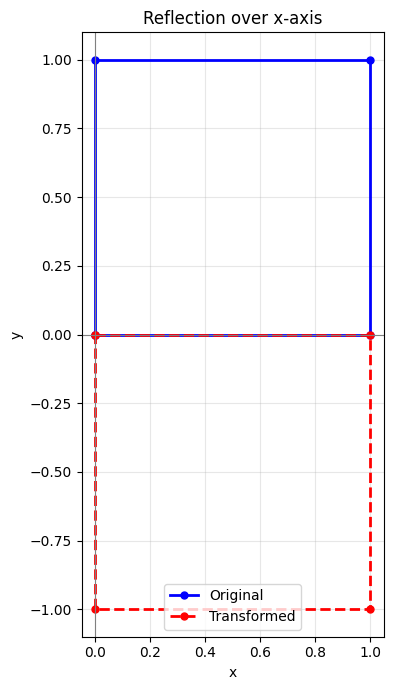

In [7]:
# ── Exercise 5 · Reflection over the x-axis ──────────────────────────────
# Map (x, y) → (x, -y) — flip vertically across the x-axis.

# Step 1: Define the reflection matrix
T = np.array([[1,0],
              [0,-1]])

# Step 2: Apply the transformation
x_new, y_new = linear_transform(T, x_shape, y_shape)

# Step 3: Plot
plot_transform(x_shape, y_shape, x_new, y_new,
               title='Reflection over x-axis')


---
## 6. Reflection over the y-axis

Flips every point across the y-axis: $(x, y) \mapsto (-x, y)$.

$$F_y = \begin{bmatrix} -1 & 0 \\ 0 & 1 \end{bmatrix}$$

### Properties
| Property | Value |
|----------|-------|
| Determinant | $-1$ (orientation reversed) |
| Eigenvalues | $-1,\ 1$ |
| Area change | None |
| Fixed points | All points on the y-axis |

### Real-world Application
- **Photo editing (horizontal flip):** The "selfie mirror" effect every front-facing phone camera applies. Instagram / Snapchat front cameras do this automatically.
- **Sprite mirroring in games:** Flipping a character sprite to face left when walking left — `canvas.scale(-1, 1)` in HTML5.
- **Optical systems:** A flat vertical mirror reflects images horizontally — modelled by this transformation.
- **Typography:** Reversed or mirrored text effects seen in logos.


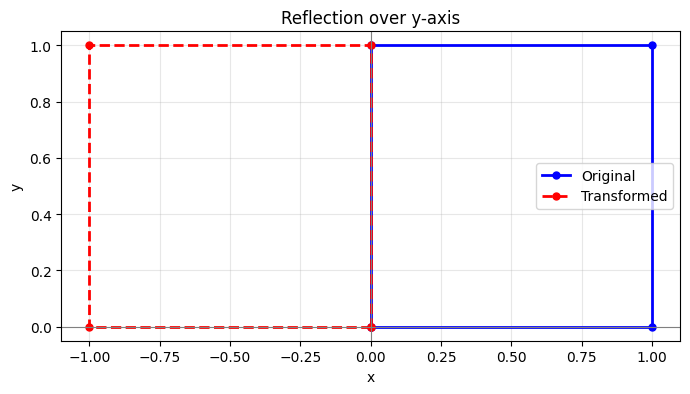

In [8]:
# ── Exercise 6 · Reflection over the y-axis ──────────────────────────────
# Map (x, y) → (-x, y) — flip horizontally across the y-axis.

# Step 1: Define the reflection matrix
T = np.array([[-1,0],
              [0,1]])

# Step 2: Apply the transformation
x_new, y_new = linear_transform(T, x_shape, y_shape)

# Step 3: Plot
plot_transform(x_shape, y_shape, x_new, y_new,
               title='Reflection over y-axis')


---
## 7. Reflection over the Origin (Point Reflection)

Sends every point to the diametrically opposite side: $(x, y) \mapsto (-x, -y)$.

$$P = \begin{bmatrix} -1 & 0 \\ 0 & -1 \end{bmatrix}$$

This is **identical** to a rotation by $180°$.

### Properties
| Property | Value |
|----------|-------|
| Determinant | $1$ (orientation preserved) |
| Eigenvalues | $-1,\ -1$ |
| Area change | None |
| Fixed points | Origin only |

### Real-world Application
- **Point symmetry in design:** Playing card symbols (♠ ♥) and many logos have point symmetry — rotating the shape $180°$ about a centre gives itself.
- **Chemistry — centrosymmetric molecules:** Benzene and other molecules with an inversion centre map back to themselves under this transformation.
- **Signal theory:** Negating both components of a 2D signal is equivalent to a $180°$ phase shift.
- **Anti-particle physics:** An antiparticle can be thought of as a particle with inverted phase-space coordinates.


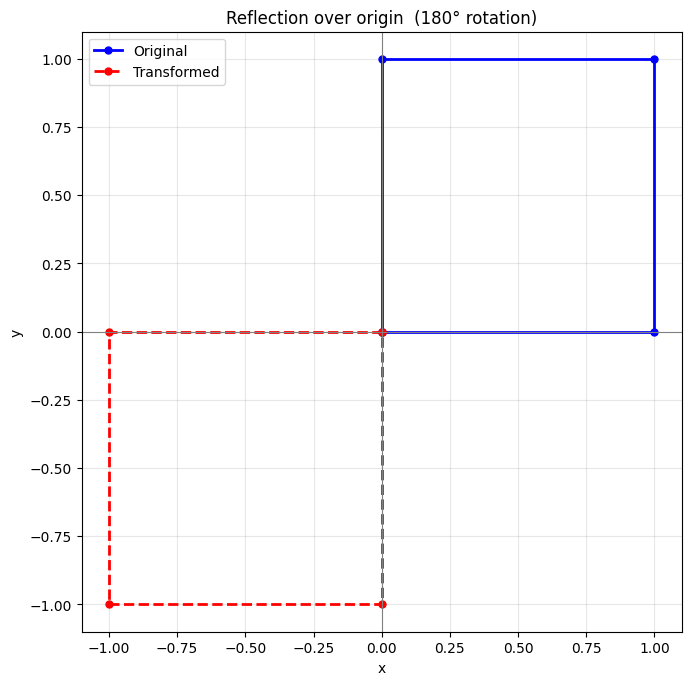

In [9]:
# ── Exercise 7 · Reflection over the origin ──────────────────────────────
# Map (x, y) → (-x, -y) — equivalent to a 180° rotation.

# Step 1: Define the point-reflection matrix
T = np.array([[-1,0],
              [0,-1]])

# Step 2: Apply the transformation
x_new, y_new = linear_transform(T, x_shape, y_shape)

# Step 3: Plot
plot_transform(x_shape, y_shape, x_new, y_new,
               title='Reflection over origin  (180° rotation)')


---
## 8. Reflection over the line y = x

Reflects every point across the diagonal $y = x$: $(x, y) \mapsto (y, x)$.

$$F_{y=x} = \begin{bmatrix} 0 & 1 \\ 1 & 0 \end{bmatrix}$$

### Properties
| Property | Value |
|----------|-------|
| Determinant | $-1$ (orientation reversed) |
| Eigenvalues | $1,\ -1$ |
| Area change | None |
| Fixed points | All points on $y = x$ |

### Real-world Application
- **Matrix transpose:** Reflecting a matrix over its main diagonal is the transpose $A^T$ — used everywhere in linear algebra, deep learning weight matrices, and signal processing.
- **Inverse functions:** Graphically, the inverse of a function $f$ is its reflection over $y = x$ (e.g., $e^x$ and $\ln x$ mirror each other across this line).
- **Coordinate system swap:** Some geospatial APIs use `(lon, lat)` while others use `(lat, lon)` — swapping them is a reflection over $y = x$.
- **Symmetric adjacency matrix:** A graph's adjacency matrix $A = A^T$ means the graph is undirected — identical to being symmetric over the main diagonal.


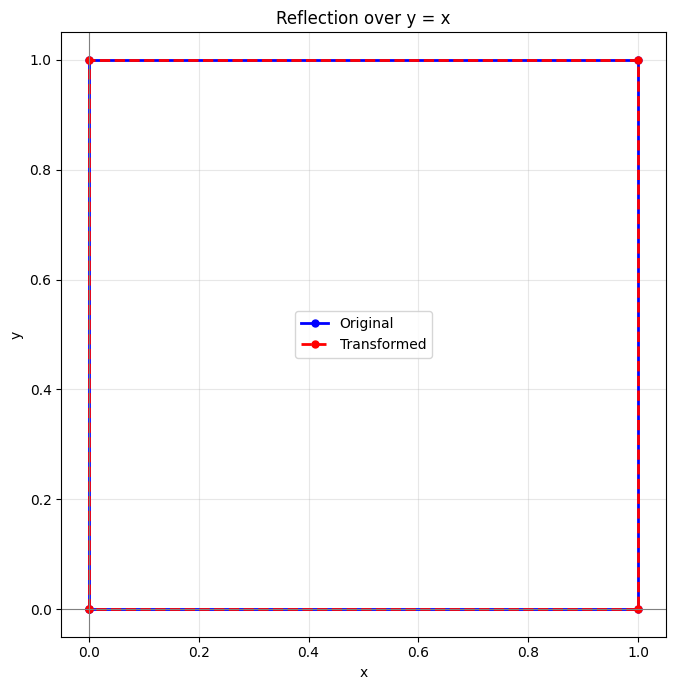

In [10]:
# ── Exercise 8 · Reflection over y = x ───────────────────────────────────
# Map (x, y) → (y, x) — swap the two coordinates.

# Step 1: Define the reflection matrix over y = x
T = np.array([[0,1],
              [1,0]])

# Step 2: Apply the transformation
x_new, y_new = linear_transform(T, x_shape, y_shape)

# Step 3: Plot
plot_transform(x_shape, y_shape, x_new, y_new,
               title='Reflection over y = x')


---
## 9. Reflection over the line y = −x

Reflects every point across the anti-diagonal $y = -x$: $(x, y) \mapsto (-y, -x)$.

$$F_{y=-x} = \begin{bmatrix} 0 & -1 \\ -1 & 0 \end{bmatrix}$$

### Properties
| Property | Value |
|----------|-------|
| Determinant | $-1$ (orientation reversed) |
| Eigenvalues | $1,\ -1$ |
| Area change | None |
| Fixed points | All points on $y = -x$ |

### Real-world Application
- **Anti-symmetric tensors:** In crystallography, certain tensors transform under anti-diagonal reflections when switching crystal axes.
- **Coordinate frame conversion:** Converting between certain left-handed and right-handed coordinate systems involves swapping and negating axes.
- **Image processing:** Diagonal (right-to-left) flip — less common than the y = x flip, but used in certain filter bank designs.
- **Combinatorics / game theory:** Mapping strategies in symmetric zero-sum games to their "mirror" anti-strategies.


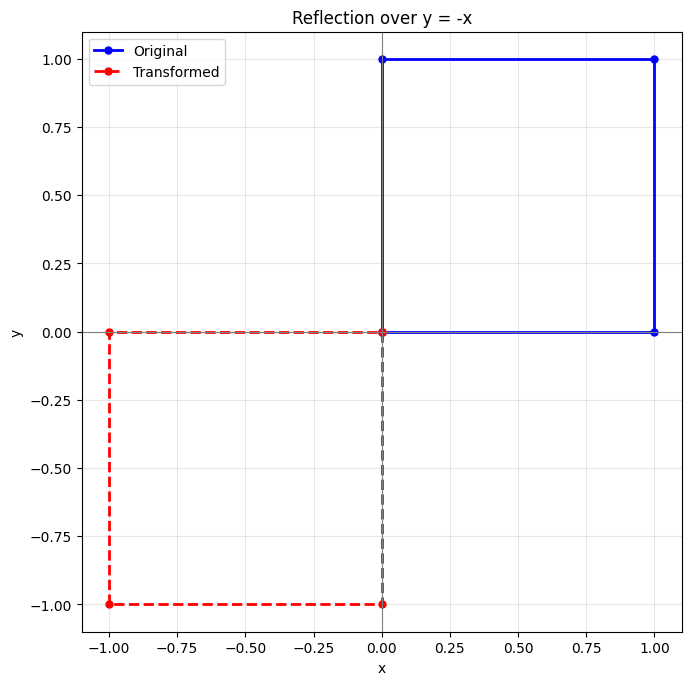

In [11]:
# ── Exercise 9 · Reflection over y = -x ──────────────────────────────────
# Map (x, y) → (-y, -x) — reflect over the anti-diagonal.

# Step 1: Define the reflection matrix over y = -x
T = np.array([[0,-1],
              [-1,0]])

# Step 2: Apply the transformation
x_new, y_new = linear_transform(T, x_shape, y_shape)

# Step 3: Plot
plot_transform(x_shape, y_shape, x_new, y_new,
               title='Reflection over y = -x')


---
## 10. Horizontal Shear

A **horizontal shear** displaces each point horizontally by an amount proportional to its y-coordinate:

$$H_x = \begin{bmatrix} 1 & k \\ 0 & 1 \end{bmatrix}
\qquad
(x,\, y) \;\mapsto\; (x + ky,\; y)$$

- Vertical lines **tilt** (become oblique)
- Horizontal lines **stay horizontal**

### Properties
| Property | Value |
|----------|-------|
| Determinant | $1$ (area-preserving!) |
| Eigenvalues | $1,\ 1$ |
| Area change | None |
| Preserves | Horizontal lines |

### Real-world Application
- **Italic text rendering:** Italic characters in fonts are often (digitally) generated by applying a horizontal shear to upright glyphs — slanting the letterforms to the right.
- **CSS / SVG transforms:** `transform: skewY(angle)` is a horizontal shear applied to HTML elements.
- **Geology (fault mechanics):** Rock layers deforming under shear stress along a horizontal fault plane follow this transformation.
- **Perspective graphics (cabinet projection):** Gives a 3D "depth" feeling from a side-on 2D drawing by shearing receding edges.


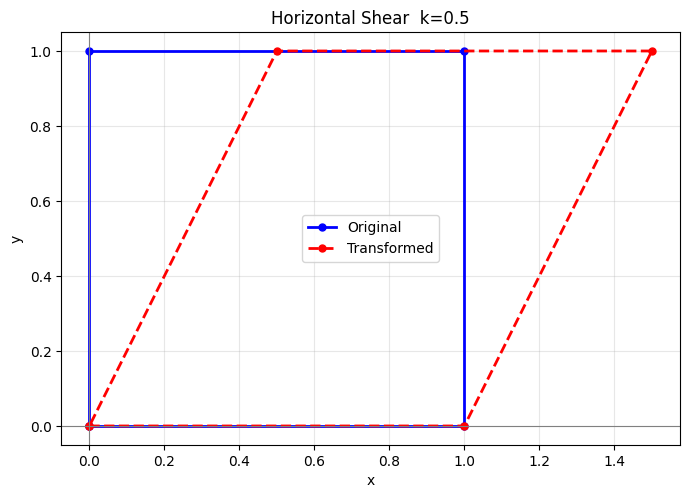

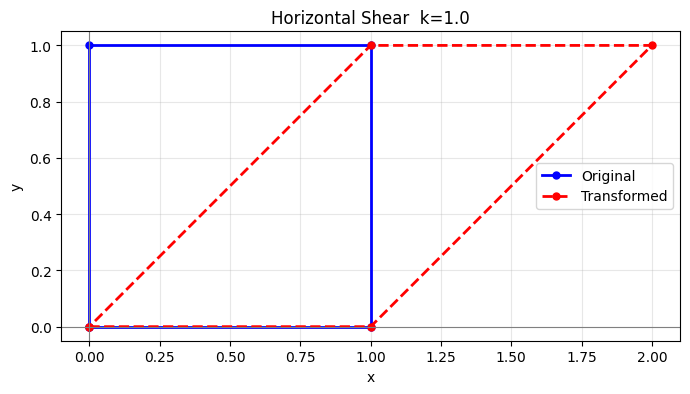

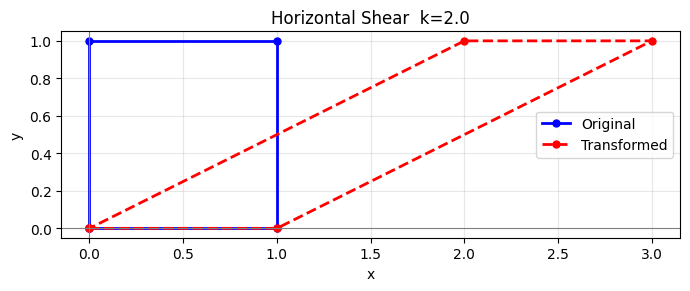

In [12]:
# ── Exercise 10 · Horizontal Shear ───────────────────────────────────────
# Map (x, y) → (x + k*y, y).  The y-value drives how far x shifts.
# Try k = 0.5, 1.0, 2.0  to see increasing slant.

k_values = [0.5, 1.0, 2.0]   # shear factor
for k in k_values:
    # Step 1: Define the horizontal shear matrix
    T = np.array([[1, k],
                  [0, 1]])
    
    # Step 2: Apply the transformation
    x_new, y_new = linear_transform(T, x_shape, y_shape)
    
    # Step 3: Plot
    plot_transform(x_shape, y_shape, x_new, y_new,
                   title=f'Horizontal Shear  k={k}')


---
## 11. Vertical Shear

A **vertical shear** displaces each point vertically by an amount proportional to its x-coordinate:

$$H_y = \begin{bmatrix} 1 & 0 \\ k & 1 \end{bmatrix}
\qquad
(x,\, y) \;\mapsto\; (x,\; y + kx)$$

- Horizontal lines **tilt** (become oblique)
- Vertical lines **stay vertical**

### Properties
| Property | Value |
|----------|-------|
| Determinant | $1$ (area-preserving!) |
| Eigenvalues | $1,\ 1$ |
| Area change | None |
| Preserves | Vertical lines |

### Real-world Application
- **CSS / canvas transforms:** `transform: skewX(angle)` applies a vertical shear to HTML elements — widely used for parallelogram UI cards.
- **2D platformer slope design:** A sloped surface segment can be represented as a vertical shear of a flat tile grid.
- **Engineering oblique drawings:** Oblique projection (used in engineering schematics) includes a vertical shear component to indicate depth.
- **Meteorology (wind shear):** Horizontal wind velocity varying with altitude creates a vertical shear of the flow streamlines.


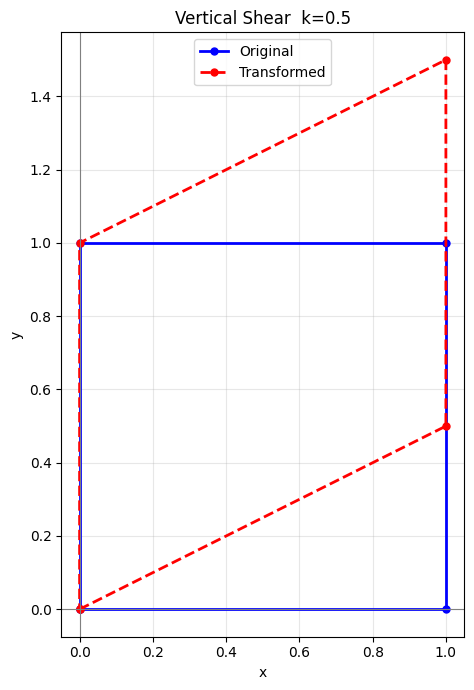

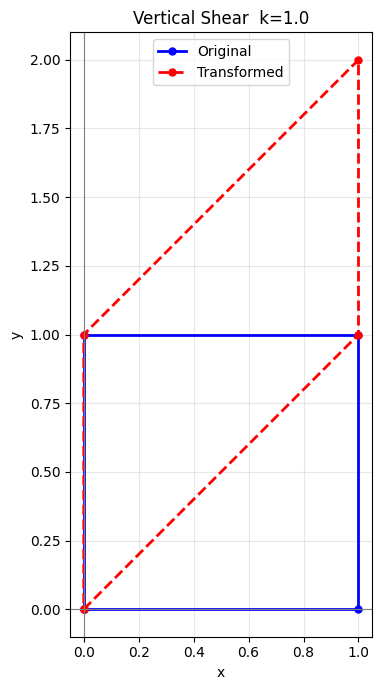

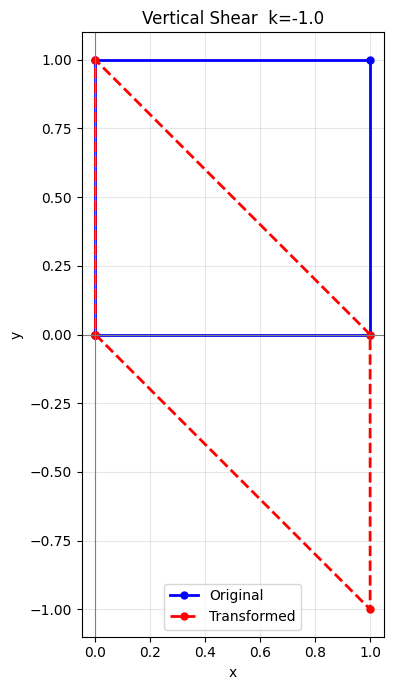

In [13]:
# ── Exercise 11 · Vertical Shear ─────────────────────────────────────────
# Map (x, y) → (x, y + k*x).  The x-value drives how far y shifts.
# Try k = 0.5, 1.0, -1.0  to see different tilt directions.

k_values = [0.5, 1.0, -1.0]   # shear factor

for k in k_values:
    # Step 1: Define the vertical shear matrix
    T = np.array([[1, 0],
                  [k, 1]])
    
    # Step 2: Apply the transformation
    x_new, y_new = linear_transform(T, x_shape, y_shape)
    
    # Step 3: Plot
    plot_transform(x_shape, y_shape, x_new, y_new,
                   title=f'Vertical Shear  k={k}')


---
## 12. Projection onto the x-axis

**Orthogonal projection** onto the x-axis collapses every point down to the x-axis:
$(x, y) \mapsto (x, 0)$.

$$P_x = \begin{bmatrix} 1 & 0 \\ 0 & 0 \end{bmatrix}$$

### Properties
| Property | Value |
|----------|-------|
| Determinant | $0$ — **singular**, not invertible |
| Rank | $1$ |
| Area change | $0$ (collapses 2D shape to a 1D line) |
| Idempotent? | Yes: $P_x^2 = P_x$ |

The **idempotent** property means projecting twice gives the same result as projecting once — you can't "more project" than once.

### Real-world Application
- **Shadow rendering:** A directional overhead light casts shadows onto the ground — points are projected to the floor plane (x-axis in 2D).
- **Dimensionality reduction (PCA):** Projecting high-dimensional data onto the first principal component direction discards all other dimensions.
- **Signal decomposition:** Extracting only the in-phase (horizontal / real) component of a 2D signal.
- **Physics:** Finding the horizontal component of a velocity/force vector by zeroing out the vertical component.


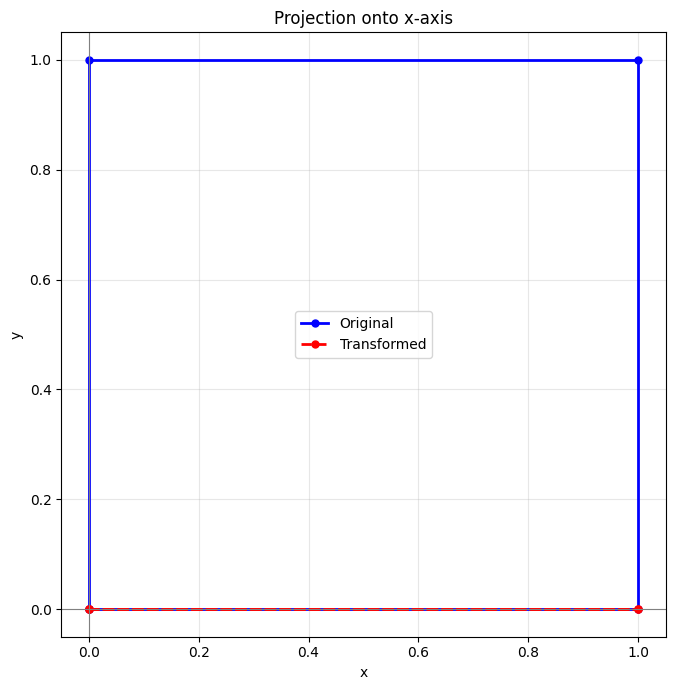

In [14]:
# ── Exercise 12 · Projection onto the x-axis ─────────────────────────────
# Map (x, y) → (x, 0) — collapse all points onto the x-axis.

# Step 1: Define the x-axis projection matrix
T = np.array([[1,0],
              [0,0]])

# Step 2: Apply the transformation
x_new, y_new = linear_transform(T, x_shape, y_shape)

# Step 3: Plot  (the result will be a flat line on y=0)
plot_transform(x_shape, y_shape, x_new, y_new,
               title='Projection onto x-axis')


---
## 13. Projection onto the y-axis

**Orthogonal projection** onto the y-axis collapses every point onto the y-axis:
$(x, y) \mapsto (0, y)$.

$$P_y = \begin{bmatrix} 0 & 0 \\ 0 & 1 \end{bmatrix}$$

### Properties
| Property | Value |
|----------|-------|
| Determinant | $0$ — **singular**, not invertible |
| Rank | $1$ |
| Area change | $0$ (collapses to a 1D line) |
| Idempotent? | Yes: $P_y^2 = P_y$ |

### Real-world Application
- **Engineering side-view drawings:** Projecting a 3D object onto the y–z plane (eliminating depth) gives the side view.
- **Signal processing:** Isolating the quadrature (vertical / imaginary) component of a 2D signal.
- **Physics:** Discarding horizontal motion and focusing only on the vertical component — e.g., analysing the height of a projectile independent of range.
- **Statistics:** Projecting 2D scatter data onto the y-axis to compute the marginal distribution in the y-direction.


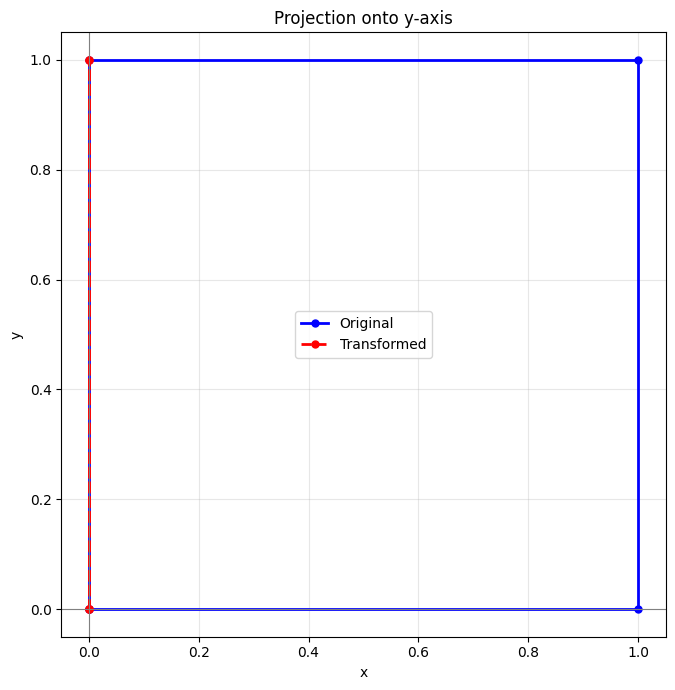

In [15]:
# ── Exercise 13 · Projection onto the y-axis ─────────────────────────────
# Map (x, y) → (0, y) — collapse all points onto the y-axis.

# Step 1: Define the y-axis projection matrix
T = np.array([[0,0],
              [0,1]])

# Step 2: Apply the transformation
x_new, y_new = linear_transform(T, x_shape, y_shape)

# Step 3: Plot  (the result will be a vertical line on x=0)
plot_transform(x_shape, y_shape, x_new, y_new,
               title='Projection onto y-axis')


---
## 14. Squeeze Mapping (Hyperbolic Rotation)

A **squeeze mapping** stretches one axis by $k$ and compresses the other by $1/k$,
keeping the **area constant**:

$$S_k = \begin{bmatrix} k & 0 \\ 0 & \tfrac{1}{k} \end{bmatrix}, \quad k > 0$$

The invariant curves are **hyperbolas** $xy = c$ — they map to themselves under the squeeze.

### Properties
| Property | Value |
|----------|-------|
| Determinant | $1$ (area-preserving!) |
| Eigenvalues | $k,\ 1/k$ |
| Area change | None |
| Invariant curves | Hyperbolas $xy = \text{const}$ |

### Real-world Application
- **Fluid mechanics (incompressible flow):** Squeezing rubber or water in one direction forces expansion in the perpendicular direction at the same rate — volume is conserved.
- **Special Relativity (Lorentz boost):** Near-light-speed boosts mix space and time coordinates in a way mathematically equivalent to a squeeze mapping in $(x, ct)$ spacetime.
- **Elastic deformation:** Stretching a uniform material in one direction while it contracts in the perpendicular direction (Poisson's ratio effect in 2D).
- **Wavelet time-frequency analysis:** The scale parameter of a wavelet transform simultaneously stretches time and compresses frequency — a squeeze in the time-frequency plane.


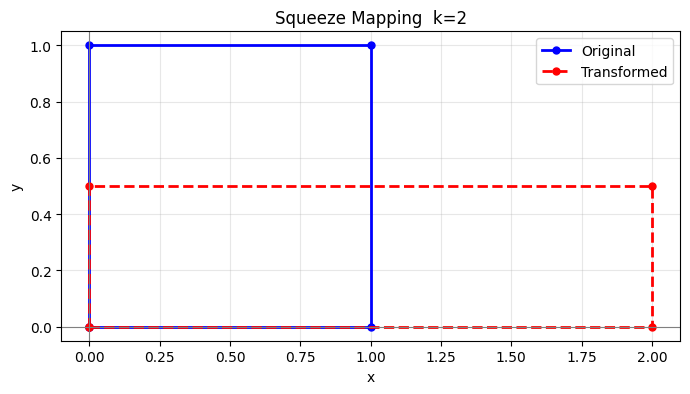

In [16]:
# ── Exercise 14 · Squeeze Mapping ────────────────────────────────────────
# Stretch the x-axis by k and compress the y-axis by 1/k.
# Area is preserved (det = 1).  Try k=2, k=0.5, k=3.

k = 2   # stretch factor  (must be > 0)

# Step 1: Define the squeeze mapping matrix
T = np.array([
    [k,     0  ],
    [0,  1 / k  ]
])

# Step 2: Apply the transformation
x_new, y_new = linear_transform(T, x_shape, y_shape)

# Step 3: Plot
plot_transform(x_shape, y_shape, x_new, y_new,
               title=f'Squeeze Mapping  k={k}')


---
## 15. Composition of Transformations

Any sequence of linear transformations can be **composed** into a single matrix:

$$C = T_n \cdots T_2 \cdot T_1$$

The **rightmost** matrix is applied **first**:
- $C = S \cdot R$ means: first rotate ($R$), then scale ($S$).

> ⚠️ **Matrix multiplication is NOT commutative in general:**
> $T_1 T_2 \neq T_2 T_1$  — **order matters!**

### Why composition matters
Instead of applying $n$ matrices one-by-one to thousands of points, compose them into **one single matrix** first and apply it once. This is a massive performance win.

### Properties
The composed matrix $C$ inherits:
- $\det(C) = \det(T_n) \cdots \det(T_1)$
- Invertibility: $C^{-1} = T_1^{-1} \cdots T_n^{-1}$ (reverse order)

### Real-world Application
- **3D graphics (MVP matrix):** Every vertex passes through $M_\text{MVP} = P \cdot V \cdot M$ (Projection × View × Model) — three separate transforms composed into one per frame.
- **Robotics (forward kinematics):** Each joint applies a rotation + translation. Composing these gives the robot end-effector pose in one matrix product.
- **Computer animation:** Keyframe interpolation blends composed transforms (rotation × scale × translation) — the transform stack in engines like Unity / Blender.
- **CNN feature maps:** Successive convolutional layers in deep learning compose learned linear transformations (in the linear approximation).

### Challenge in this exercise
Apply **Rotation → Scale** and then **Scale → Rotation** and observe that the results differ!


[[ 1.41421356 -1.41421356]
 [ 0.35355339  0.35355339]]


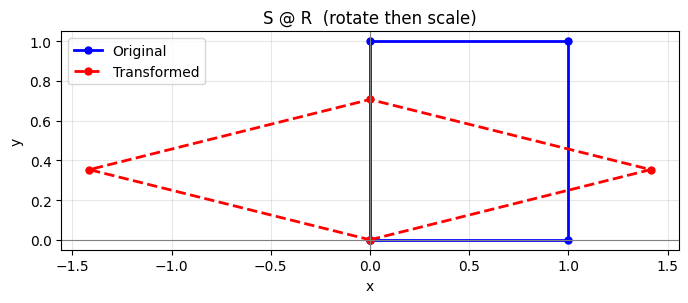

[[ 1.41421356 -0.35355339]
 [ 1.41421356  0.35355339]]


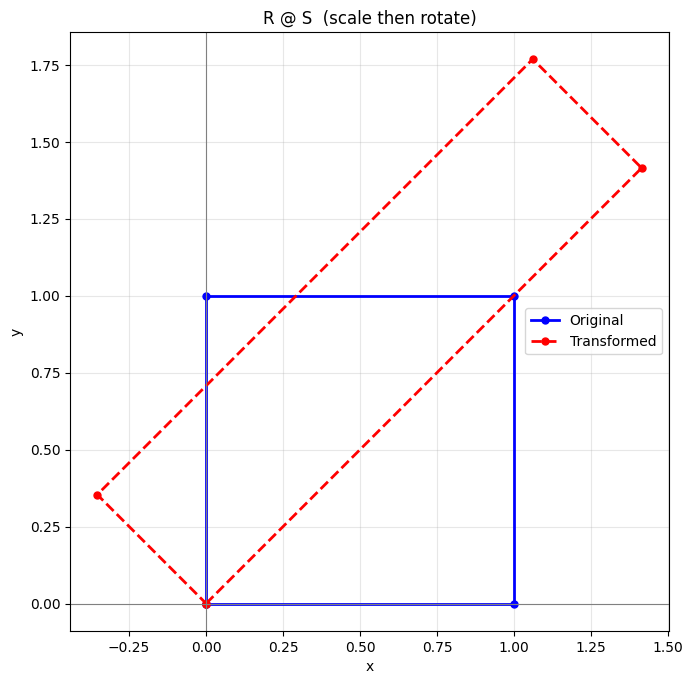

In [17]:
# ── Exercise 15 · Composition of Transformations ─────────────────────────
# Combine a rotation and a non-uniform scale in TWO different orders
# and observe that the results are different.

theta = np.radians(45)
kx, ky = 2.0, 0.5

# Step 1: Build the rotation matrix R
R = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
])

# Step 2: Build the non-uniform scale matrix S
S = np.array([
    [kx,  0],
    [ 0, ky]
])

# Step 3: Compose  C1 = S @ R  — rotate FIRST, then scale
C1 = S @ R
x1, y1 = linear_transform(C1, x_shape, y_shape)
print(C1)
plot_transform(x_shape, y_shape, x1, y1,
               title='S @ R  (rotate then scale)')

# Step 4: Compose  C2 = R @ S  — scale FIRST, then rotate
C2 = R @ S
x2, y2 = linear_transform(C2, x_shape, y_shape)
print(C2)
plot_transform(x_shape, y_shape, x2, y2,
               title='R @ S  (scale then rotate)')
